In [6]:
import pandas as pd 
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

# 경로를 지정하여 Graphviz를 설치한 경우, 다음과 같이 경로를 설정할 수 있습니다.
from sklearn.tree import export_graphviz
import graphviz


In [7]:
# 데이터 로드
wine = load_wine()

In [9]:
# 데이터 프레임 생성
df = pd.DataFrame(wine.data, columns=wine.feature_names)

In [11]:
df['target'] = wine.target

In [12]:
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [13]:
# EDA (탐색적 데이터 분석)

print(df.shape)

(178, 14)


In [15]:
df.describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


In [ ]:
df['target'].value_counts() # 총 3가지 와인 품종이 있군

,count
target,
1,71
0,59
2,48


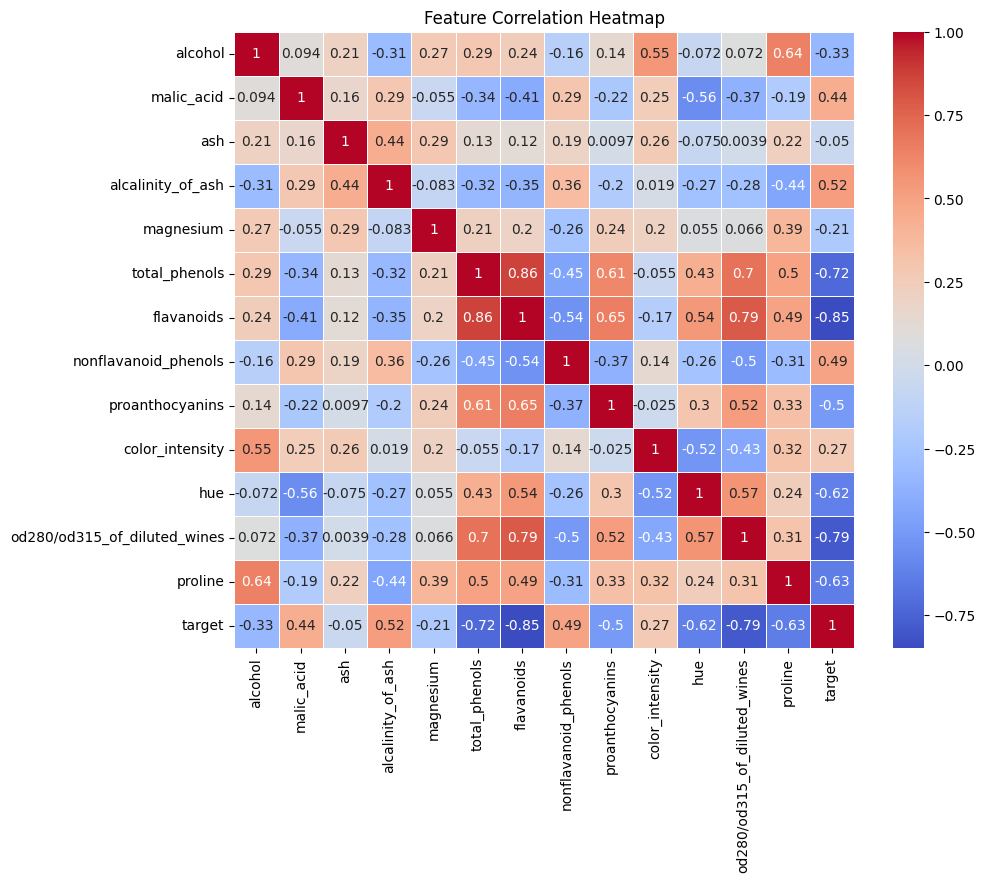

In [17]:
# 특성 간 상관 관계 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.show()

In [ ]:
# 모형 학습
# 특성과 타겟의 데이터를 분리
X = df.drop('target', axis=1)
y = df['target']    

In [20]:
# 학습 데이터와 테스트 데이터로 분리(80% 학습, 20% 테스트)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
# Decision Tree 모델 학습

clf = DecisionTreeClassifier(criterion= 'entropy')
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy')

In [23]:
X_test

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
19,13.64,3.10,2.56,15.2,116.0,2.70,3.03,0.17,1.66,5.100000,0.96,3.36,845.0
45,14.21,4.04,2.44,18.9,111.0,2.85,2.65,0.30,1.25,5.240000,0.87,3.33,1080.0
140,12.93,2.81,2.70,21.0,96.0,1.54,0.50,0.53,0.75,4.600000,0.77,2.31,600.0
30,13.73,1.50,2.70,22.5,101.0,3.00,3.25,0.29,2.38,5.700000,1.19,2.71,1285.0
67,12.37,1.17,1.92,19.6,78.0,2.11,2.00,0.27,1.04,4.680000,1.12,3.48,510.0
16,14.30,1.92,2.72,20.0,120.0,2.80,3.14,0.33,1.97,6.200000,1.07,2.65,1280.0
119,12.00,3.43,2.00,19.0,87.0,2.00,1.64,0.37,1.87,1.280000,0.93,3.05,564.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.300000,0.70,1.56,750.0
109,11.61,1.35,2.70,20.0,94.0,2.74,2.92,0.29,2.49,2.650000,0.96,3.26,680.0
141,13.36,2.56,2.35,20.0,89.0,1.40,0.50,0.37,0.64,5.600000,0.70,2.47,780.0


In [22]:
# 테스트를 위한 분류
y_pred = clf.predict(X_test)

In [24]:
y_pred

array([0, 0, 1, 0, 1, 0, 1, 2, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 1,
       1, 2, 2, 2, 1, 1, 1, 0, 0, 1, 2, 0, 0, 0])

In [26]:
# 정확도 계산 및 분류 보고서 출력
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.9167


In [27]:
print('\n Classification Report:', classification_report(y_test, y_pred))


 Classification Report:               precision    recall  f1-score   support

           0       0.93      1.00      0.97        14
           1       0.88      1.00      0.93        14
           2       1.00      0.62      0.77         8

    accuracy                           0.92        36
   macro avg       0.94      0.88      0.89        36
weighted avg       0.93      0.92      0.91        36



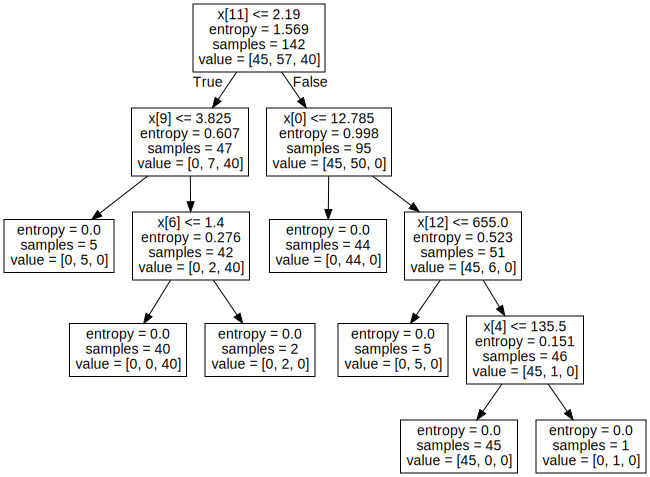

In [ ]:
# 의사결정 나무를 시각화 
dot_data = export_graphviz(clf, out_file=None)
# Graphviz로 시각화
graph = graphviz.Source(dot_data)
# 저장 및 표시
graph.render("decision_tree_wine")
graph 